<a href="https://colab.research.google.com/github/fernandovidalnn/Colab-Mineria-de-datos/blob/main/tarea_modelo_de_la_canasta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo de la canasta

https://www.kaggle.com/datasets/prasad22/retail-transactions-dataset

In [1]:
import warnings
warnings.simplefilter("ignore")


In [2]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
pip install --upgrade jupyter_client jupyter-core

In [4]:
!pip install squarify

In [5]:
!pip3 install mlxtend

In [6]:
!pip3 install pandas numpy matplotlib squarify scikit-learn

In [7]:
import sys
!{sys.executable} -m pip install mlxtend

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import squarify

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# LECTURA DE LOS DATOS

In [9]:
%%capture
df = pd.read_csv("Retail_Transactions_Dataset.csv")

In [10]:
df.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


# Visualización de los datos

In [11]:
df.columns

Index(['Transaction_ID', 'Date', 'Customer_Name', 'Product', 'Total_Items',
       'Total_Cost', 'Payment_Method', 'City', 'Store_Type',
       'Discount_Applied', 'Customer_Category', 'Season', 'Promotion'],
      dtype='object')

In [12]:
# Convierte los productos desde texto a listas reales
df['Product'] = df['Product'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [13]:
# Muestra las primeras filas de la columna Product
df['Product'].head()

,Product
0,"[Ketchup, Shaving Cream, Light Bulbs]"
1,"[Ice Cream, Milk, Olive Oil, Bread, Potatoes]"
2,[Spinach]
3,"[Tissues, Mustard]"
4,[Dish Soap]


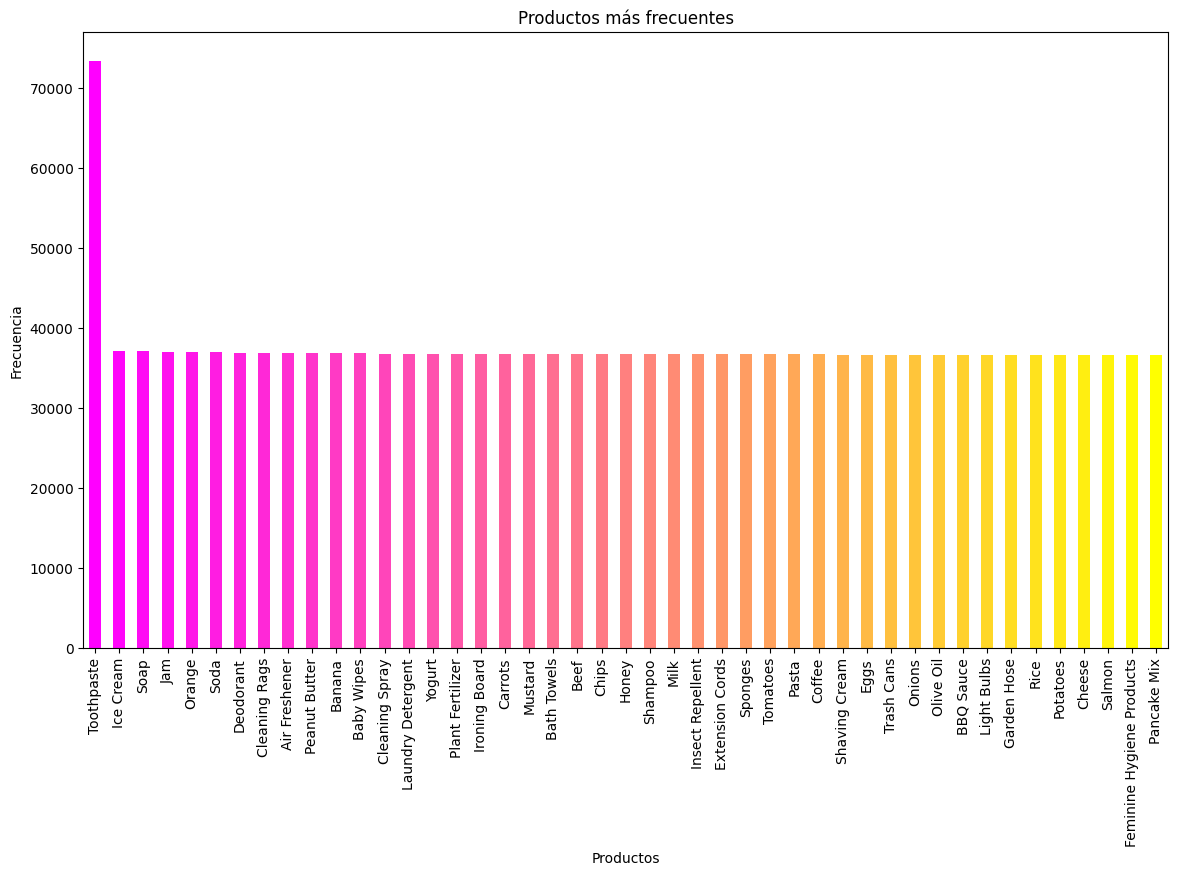

In [14]:
# Une todos los productos y cuenta su frecuencia para graficar los más comprados
productos = []

for lista in df['Product']:
    if isinstance(lista, list):
        productos.extend(lista)

productos = pd.Series(productos)

df_sum = productos.value_counts()

plt.figure(figsize=(14,8))
plt.title("Productos más frecuentes")

cnt = 45
color = plt.cm.spring(np.linspace(0, 1, cnt))

df_sum.head(cnt).plot.bar(color=color)

plt.xticks(rotation='vertical')
plt.xlabel("Productos")
plt.ylabel("Frecuencia")
plt.grid(False)

plt.show()

En el gráfico se observa que la mayoría de los productos presentan frecuencias similares, mientras que Toothpaste destaca como el producto con mayor número de apariciones en las transacciones.

# Mapa de calor de los productos más frecuentes.

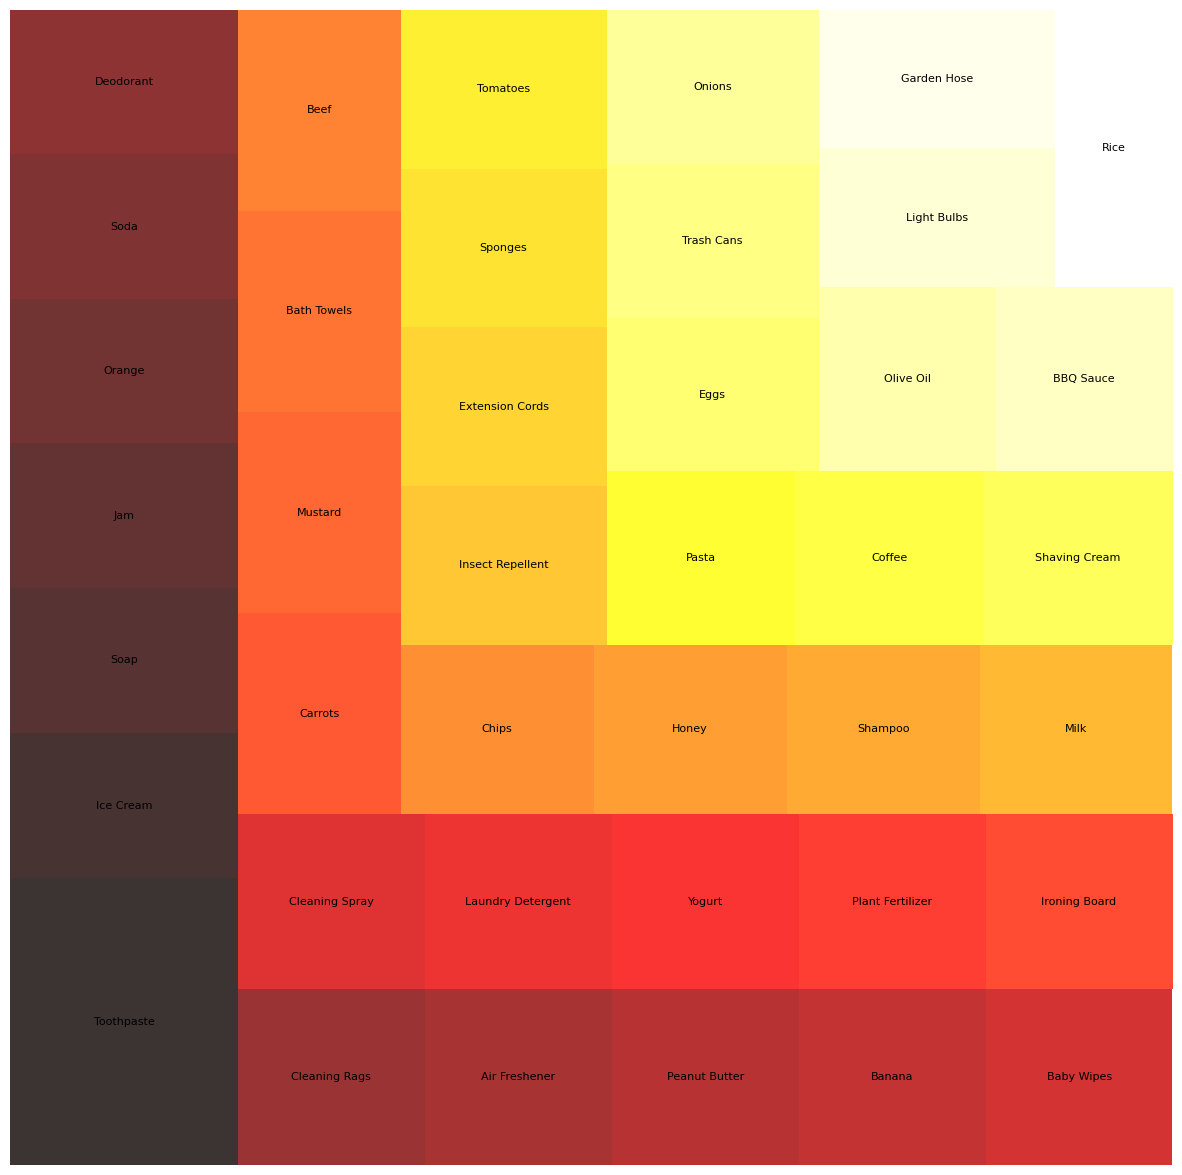

In [15]:
plt.figure(figsize=(15,15))

cnt = 40
color = plt.cm.hot(np.linspace(0, 1, cnt))

df_part = df_sum.head(cnt)

squarify.plot(
    sizes=df_part.values,
    label=df_part.index,
    alpha=.8,
    color=color,
    text_kwargs={'fontsize':8}
)

plt.axis('off')
plt.show()

El gráfico muestra los productos con mayor frecuencia dentro de las transacciones del dataset. Cada rectángulo representa un producto y su tamaño indica la cantidad de veces que aparece en las compras realizadas por los clientes. Productos como Toothpaste, Ice Cream y Soap destacan por tener una mayor presencia en comparación con otros artículos. Los diferentes colores permiten diferenciar visualmente los productos y facilitar el análisis de patrones de compra en el modelo de la canasta.

In [16]:
# Creación de las transacciones de compra.
# Este código crea una lista de transacciones con los productos
# comprados por cada cliente y muestra las primeras cinco compras registradas.
arr = [lista for lista in df['Product'] if isinstance(lista, list)]

arr[:5]

[['Ketchup', 'Shaving Cream', 'Light Bulbs'],
 ['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'Potatoes'],
 ['Spinach'],
 ['Tissues', 'Mustard'],
 ['Dish Soap']]

# Transformación de datos transaccionales.
Este código convierte las transacciones en una matriz binaria donde cada columna representa un producto y cada fila una compra. Los valores True y False indican si un producto está presente o no en la transacción.

aplicamos modelo de la canasta

In [17]:
te = TransactionEncoder()

data = te.fit_transform(arr)

data = pd.DataFrame(data, columns=te.columns_)

data.head()

,Air Freshener,Apple,BBQ Sauce,Baby Wipes,Banana,Bath Towels,Beef,Bread,Broom,Butter,...,Tomatoes,Toothbrush,Toothpaste,Trash Bags,Trash Cans,Tuna,Vacuum Cleaner,Vinegar,Water,Yogurt
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# REGLAS APRIORI

## Aplicación del algoritmo Apriori.
Este código aplica el algoritmo Apriori para identificar combinaciones frecuentes de productos dentro de las transacciones, utilizando un soporte mínimo de 0.01. Luego, se muestran las primeras reglas encontradas.

modelo de la canasta mediante apriori

In [18]:
freq_rules = apriori(
    data,
    min_support=0.01,
    use_colnames=True
)

freq_rules.head()

,support,itemsets
0,0.036266,(Air Freshener)
1,0.035748,(Apple)
2,0.036046,(BBQ Sauce)
3,0.036196,(Baby Wipes)
4,0.036224,(Banana)


## Cálculo de longitud de combinaciones
Este código agrega una columna llamada length que indica la cantidad de productos presentes en cada combinación encontrada por el algoritmo Apriori.

In [19]:
freq_rules['length'] = freq_rules['itemsets'].apply(lambda x: len(x))

freq_rules.head()

,support,itemsets,length
0,0.036266,(Air Freshener),1
1,0.035748,(Apple),1
2,0.036046,(BBQ Sauce),1
3,0.036196,(Baby Wipes),1
4,0.036224,(Banana),1


In [20]:
data.head(10)

,Air Freshener,Apple,BBQ Sauce,Baby Wipes,Banana,Bath Towels,Beef,Bread,Broom,Butter,...,Tomatoes,Toothbrush,Toothpaste,Trash Bags,Trash Cans,Tuna,Vacuum Cleaner,Vinegar,Water,Yogurt
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
6,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Filtrado de reglas frecuentes.
Este código filtra las combinaciones que contienen más de un producto, mostrando únicamente las asociaciones frecuentes entre artículos comprados juntos.

In [21]:
mask = freq_rules['length'] > 1

filtered_freq_rules = freq_rules.loc[mask]

filtered_freq_rules.head(20)

,support,itemsets,length
